# Mode Dynamics Walkthrough

Goal: train a small network on `y = sin(x)` and check whether learning dynamics collapse into a low-dimensional set of update modes.

## 1) Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from mode_dynamics import (
    SineMLP,
    build_sine_dataset,
    train_with_tracking,
)

np.random.seed(0)
torch.manual_seed(0)

## 2) Dataset

In [2]:
n_samples = 5000
x_train, y_train = build_sine_dataset(
    n_samples=n_samples,
    seed=0,
)

print('Train:', x_train.shape, y_train.shape)

Train: torch.Size([5000, 1]) torch.Size([5000, 1])


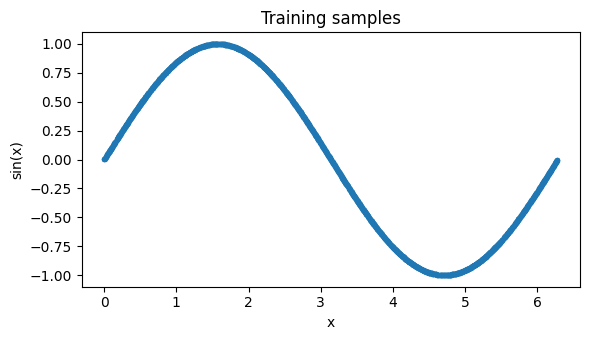

In [3]:
plt.figure(figsize=(6, 3.5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=8, alpha=0.45)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Training samples')
plt.tight_layout()
plt.show()

## 3) Model

In [4]:
hidden_dim = 2
model = SineMLP(hidden_dim=hidden_dim)
print(model)
print('Total params:', sum(p.numel() for p in model.parameters()))

SineMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)
Total params: 7


## 4) Train and track dynamics

In [5]:
snapshot_epochs = [1000, 5000, 10000, 20000, 40000, 80000]
tracked = train_with_tracking(
    model=model,
    x_train=x_train,
    y_train=y_train,
    n_epochs=80000,
    lr=0.01,
    checkpoint_every=10,
    snapshot_epochs=snapshot_epochs,
)

train_losses = tracked['train_losses']
checkpoint_epochs = tracked['checkpoint_epochs']
weight_matrix = tracked['checkpoint_weights']
snapshots = tracked['snapshots']

print('Training complete')
print('Weight matrix shape:', weight_matrix.shape)

Training complete
Weight matrix shape: (8001, 7)


## 5) Loss curve

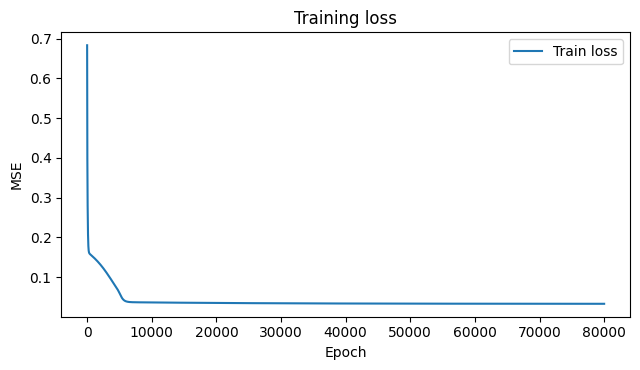

In [6]:
epochs = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(6.5, 3.8))
plt.plot(epochs, train_losses, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training loss')
plt.legend()
plt.tight_layout()
plt.show()

## 6) Function predictions over time

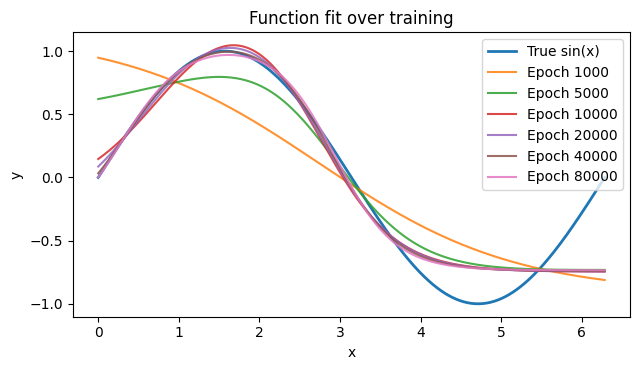

In [7]:
x_plot = torch.linspace(0.0, 2.0 * np.pi, 400).view(-1, 1)
y_true = torch.sin(x_plot).numpy()

plt.figure(figsize=(6.5, 3.8))
plt.plot(x_plot.numpy(), y_true, label='True sin(x)', linewidth=2)
for ep in snapshot_epochs:
    temp_model = SineMLP(hidden_dim=hidden_dim)
    temp_model.load_state_dict(snapshots[ep])
    temp_model.eval()
    with torch.no_grad():
        y_pred = temp_model(x_plot).numpy()
    plt.plot(x_plot.numpy(), y_pred, label=f'Epoch {ep}', alpha=0.85)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Function fit over training')
plt.legend()
plt.tight_layout()
plt.show()

## 7) Weights vs epoch

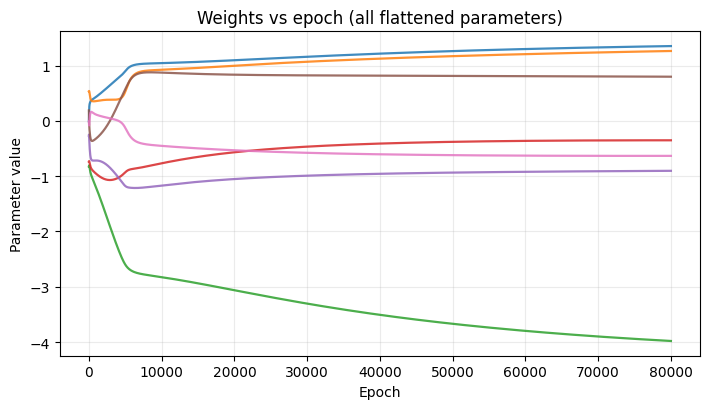

In [8]:
plt.figure(figsize=(7.2, 4.2))
for i in range(weight_matrix.shape[1]):
    plt.plot(
        checkpoint_epochs,
        weight_matrix[:, i],
        color=plt.cm.tab10(i % 10),
        alpha=0.85,
        linewidth=1.6,
    )

plt.xlabel('Epoch')
plt.ylabel('Parameter value')
plt.title('Weights vs epoch (all flattened parameters)')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Velocity dynamics (weight updates)

Here we analyze velocity vectors in parameter space:
- $v_t = \theta_{t+1} - \theta_t$
- speed: $\|v_t\|$
- top mode coefficients: $a_{k,t} = u_k^\top v_t$ from SVD of the velocity matrix.

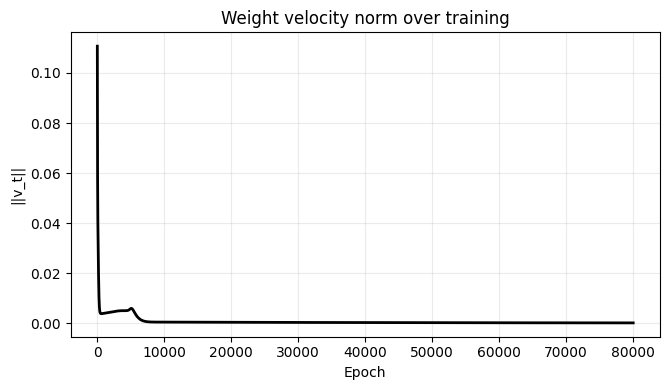

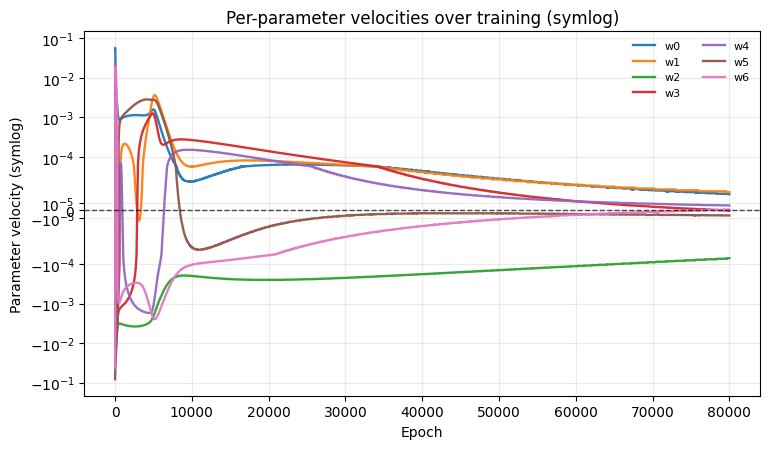

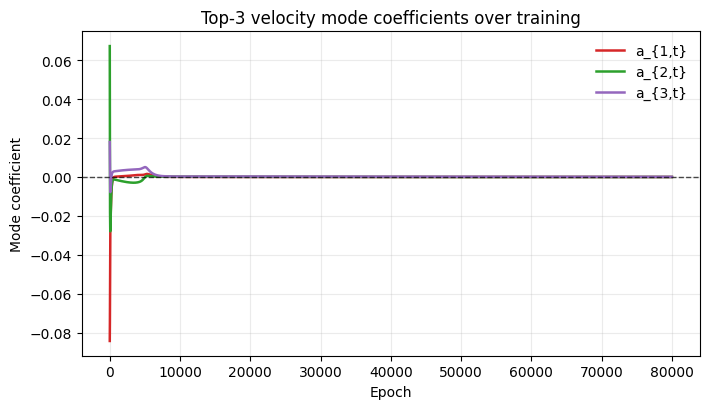

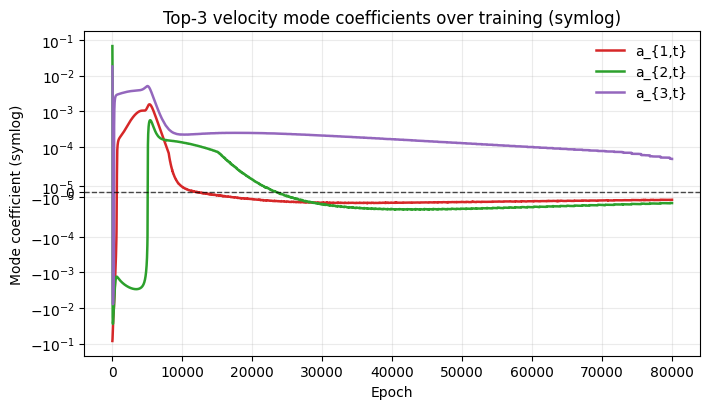

In [9]:
# Velocity matrix from tracked checkpoints
velocity_matrix = np.diff(weight_matrix, axis=0)  # shape: (num_checkpoints-1, num_params)
velocity_epochs = checkpoint_epochs[1:]
velocity_norm = np.linalg.norm(velocity_matrix, axis=1)

# 1) Speed of learning in weight space: ||v_t||
plt.figure(figsize=(6.8, 4.0))
plt.plot(velocity_epochs, velocity_norm, color='black', linewidth=2.0)
plt.xlabel('Epoch')
plt.ylabel('||v_t||')
plt.title('Weight velocity norm over training')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Velocity of each individual weight/parameter (signed log scale)
# symlog preserves sign while compressing large early spikes.
plt.figure(figsize=(7.8, 4.6))
for i in range(velocity_matrix.shape[1]):
    plt.plot(
        velocity_epochs,
        velocity_matrix[:, i],
        color=plt.cm.tab10(i % 10),
        alpha=0.95,
        linewidth=1.7,
        label=f'w{i}',
    )

linthresh = max(1e-6, np.quantile(np.abs(velocity_matrix), 0.60))
plt.yscale('symlog', linthresh=linthresh, linscale=1.0, base=10)

plt.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Parameter velocity (symlog)')
plt.title('Per-parameter velocities over training (symlog)')
plt.grid(alpha=0.25, which='both')
plt.legend(ncol=2, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

# 3) Top-3 mode coefficients a_{k,t} from SVD(V)
# V = U S W^T, where rows of W^T (or columns of W) are parameter-space modes.
_u_time, _s_vals, vh_modes = np.linalg.svd(velocity_matrix, full_matrices=False)
top_k = 3
top_modes = vh_modes[:top_k]  # shape: (k, num_params)
mode_coeffs = velocity_matrix @ top_modes.T  # shape: (num_steps, k)

plt.figure(figsize=(7.2, 4.2))
mode_colors = ['tab:red', 'tab:green', 'tab:purple']
for k in range(top_k):
    plt.plot(velocity_epochs, mode_coeffs[:, k], label=f'a_{{{k+1},t}}', linewidth=1.8, color=mode_colors[k])
plt.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Mode coefficient')
plt.title('Top-3 velocity mode coefficients over training')
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# 4) Top-3 mode coefficients on signed-log scale (symlog)
# Keeps sign while revealing small late-stage coefficients.
plt.figure(figsize=(7.2, 4.2))
for k in range(top_k):
    plt.plot(velocity_epochs, mode_coeffs[:, k], label=f'a_{{{k+1},t}}', linewidth=1.8, color=mode_colors[k])

mode_linthresh = max(1e-8, np.quantile(np.abs(mode_coeffs), 0.60))
plt.yscale('symlog', linthresh=mode_linthresh, linscale=1.0, base=10)

plt.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Mode coefficient (symlog)')
plt.title('Top-3 velocity mode coefficients over training (symlog)')
plt.grid(alpha=0.25, which='both')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()